<a href="https://colab.research.google.com/github/dibullap/Brest-cancer-genee-expression-data-mining-project/blob/main/An%C3%A1lisis_exploratorio_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Expresión génica en el cáncer de mama.
> Análisis exploratorio en un conjunto de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches
from matplotlib.patches import Arc
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "METABRIC_RNA_Mutation.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "raghadalharbi/breast-cancer-gene-expression-profiles-metabric",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipython-input-1097637550.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'breast-cancer-gene-expression-profiles-metabric' dataset.


/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:91: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [ ]:
df.shape

(1904, 693)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Columns: 693 entries, patient_id to siah1_mut
dtypes: float64(498), int64(5), object(190)
memory usage: 10.1+ MB


In [ ]:
df.columns[:50]

Index(['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
       'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy',
       'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc',
       'er_status', 'neoplasm_histologic_grade',
       'her2_status_measured_by_snp6', 'her2_status',
       'tumor_other_histologic_subtype', 'hormone_therapy',
       'inferred_menopausal_state', 'integrative_cluster',
       'primary_tumor_laterality', 'lymph_nodes_examined_positive',
       'mutation_count', 'nottingham_prognostic_index', 'oncotree_code',
       'overall_survival_months', 'overall_survival', 'pr_status',
       'radio_therapy', '3-gene_classifier_subtype', 'tumor_size',
       'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten',
       'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1',
       'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').columns[:50]

Index(['type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed',
       'cellularity', 'pam50_+_claudin-low_subtype',
       'er_status_measured_by_ihc', 'er_status',
       'her2_status_measured_by_snp6', 'her2_status',
       'tumor_other_histologic_subtype', 'inferred_menopausal_state',
       'integrative_cluster', 'primary_tumor_laterality', 'oncotree_code',
       'pr_status', '3-gene_classifier_subtype', 'death_from_cancer',
       'pik3ca_mut', 'tp53_mut', 'muc16_mut', 'ahnak2_mut', 'kmt2c_mut',
       'syne1_mut', 'gata3_mut', 'map3k1_mut', 'ahnak_mut', 'dnah11_mut',
       'cdh1_mut', 'dnah2_mut', 'kmt2d_mut', 'ush2a_mut', 'ryr2_mut',
       'dnah5_mut', 'herc2_mut', 'pde4dip_mut', 'akap9_mut', 'tg_mut',
       'birc6_mut', 'utrn_mut', 'tbx3_mut', 'col6a3_mut', 'arid1a_mut',
       'lama2_mut', 'notch1_mut', 'cbfb_mut', 'ncor2_mut', 'col12a1_mut',
       'col22a1_mut', 'pten_mut', 'akt1_mut'],
      dtype='object')

Para identificar qué columnas podemos usar como target en los análisis se analizan las más opcionadas

In [ ]:
df[['overall_survival',
    'death_from_cancer',
    'tumor_stage',
    'pam50_+_claudin-low_subtype']].nunique()

,0
overall_survival,2
death_from_cancer,3
tumor_stage,5
pam50_+_claudin-low_subtype,7


Debido a que es una variable binaria se escoge overall survival como target del análisis, por lo que se procede a determinar si el dataset está balanceado

In [ ]:
df['overall_survival'].value_counts(normalize=True)

,proportion
overall_survival,
0,0.579307
1,0.420693


This file includes 31 clinical attributes, m-RNA levels z-score for 331 genes, and mutation in 175 genes for 1904 breast cancer patients

In [ ]:
# pd.set_option('display.max_rows', None)  # Muestra todas las filas
# df.columns.to_list()

In [ ]:
vars_mutaciones=['pik3ca_mut','tp53_mut','muc16_mut', 'ahnak2_mut', 'kmt2c_mut', 'syne1_mut', 'gata3_mut', 'map3k1_mut', 'ahnak_mut', 'dnah11_mut', 'cdh1_mut', 'dnah2_mut', 'kmt2d_mut', 'ush2a_mut', 'ryr2_mut', 'dnah5_mut', 'herc2_mut', 'pde4dip_mut', 'akap9_mut', 'tg_mut', 'birc6_mut', 'utrn_mut', 'tbx3_mut', 'col6a3_mut', 'arid1a_mut', 'lama2_mut', 'notch1_mut', 'cbfb_mut', 'ncor2_mut', 'col12a1_mut', 'col22a1_mut', 'pten_mut', 'akt1_mut', 'atr_mut', 'thada_mut', 'ncor1_mut', 'stab2_mut', 'myh9_mut', 'runx1_mut', 'nf1_mut', 'map2k4_mut', 'ros1_mut', 'lamb3_mut', 'arid1b_mut', 'erbb2_mut', 'sf3b1_mut', 'shank2_mut', 'ep300_mut', 'ptprd_mut', 'usp9x_mut', 'setd2_mut', 'setd1a_mut', 'thsd7a_mut', 'afdn_mut', 'erbb3_mut', 'rb1_mut', 'myo1a_mut', 'alk_mut', 'fanca_mut', 'adgra2_mut', 'ubr5_mut', 'pik3r1_mut', 'myo3a_mut', 'asxl2_mut', 'apc_mut', 'ctcf_mut', 'asxl1_mut', 'fancd2_mut', 'taf1_mut', 'kdm6a_mut', 'ctnna3_mut', 'brca1_mut', 'ptprm_mut', 'foxo3_mut', 'usp28_mut', 'gldc_mut', 'brca2_mut', 'cacna2d3_mut', 'arid2_mut', 'aff2_mut', 'lifr_mut', 'sbno1_mut', 'kdm3a_mut', 'ncoa3_mut', 'bap1_mut', 'l1cam_mut', 'pbrm1_mut', 'chd1_mut', 'jak1_mut', 'setdb1_mut', 'fam20c_mut', 'arid5b_mut', 'egfr_mut', 'map3k10_mut', 'smarcc2_mut', 'erbb4_mut', 'npnt_mut', 'nek1_mut', 'agmo_mut', 'zfp36l1_mut', 'smad4_mut', 'sik1_mut', 'casp8_mut', 'prkcq_mut', 'smarcc1_mut', 'palld_mut', 'dcaf4l2_mut', 'bcas3_mut', 'cdkn1b_mut', 'gps2_mut', 'men1_mut', 'stk11_mut', 'sik2_mut', 'ptpn22_mut', 'brip1_mut', 'flt3_mut', 'nrg3_mut', 'fbxw7_mut', 'ttyh1_mut', 'taf4b_mut', 'or6a2_mut', 'map3k13_mut', 'hdac9_mut', 'prkacg_mut', 'rpgr_mut', 'large1_mut', 'foxp1_mut', 'clk3_mut', 'prkcz_mut', 'lipi_mut', 'ppp2r2a_mut', 'prkce_mut', 'gh1_mut', 'gpr32_mut', 'kras_mut', 'nf2_mut', 'chek2_mut', 'ldlrap1_mut', 'clrn2_mut', 'acvrl1_mut', 'agtr2_mut', 'cdkn2a_mut', 'ctnna1_mut', 'magea8_mut', 'prr16_mut', 'dtwd2_mut', 'akt2_mut', 'braf_mut', 'foxo1_mut', 'nt5e_mut', 'ccnd3_mut', 'nr3c1_mut', 'prkg1_mut', 'tbl1xr1_mut', 'frmd3_mut', 'smad2_mut', 'sgcd_mut', 'spaca1_mut', 'rasgef1b_mut', 'hist1h2bc_mut', 'nr2f1_mut', 'klrg1_mut', 'mbl2_mut', 'mtap_mut', 'ppp2cb_mut', 'smarcd1_mut', 'nras_mut', 'ndfip1_mut', 'hras_mut', 'prps2_mut', 'smarcb1_mut', 'stmn2_mut', 'siah1_mut']
vars_medicas=['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage', 'death_from_cancer']
cols_conocidas=vars_mutaciones+vars_medicas
vars_expr_genica=[col for col in df.columns if col not in cols_conocidas]

In [ ]:
print(f'% Variables de expresión genica (m-RNA z-score): {len(vars_expr_genica)/len(df.columns):.2f} - {len(vars_expr_genica)}')
print(f'% Variables de mutaciones (binaria): {len(vars_mutaciones)/len(df.columns):.2f} - {len(vars_mutaciones)}')
print(f'% Variables de medicas: {len(vars_medicas)/len(df.columns):.2f} - {len(vars_medicas)}')

% Variables de expresión genica (m-RNA z-score): 0.71 - 489
% Variables de mutaciones (binaria): 0.25 - 173
% Variables de medicas: 0.04 - 31


**clinical attributes**

| Variable | Descripción |
|----------|-------------|
| `patient_id` | Identificador único del paciente (ej. MB-XXXX).  |
| `age_at_diagnosis` | Edad del paciente al momento del diagnóstico (años).  |
| `type_of_breast_surgery` | Tipo de cirugía mamaria: MASTECTOMY (mastectomía), BREAST CONSERVING (cirugía conservadora).  |
| `cancer_type` | Tipo general de cáncer: casi siempre "Breast Cancer".  |
| `cancer_type_detailed` | Tipo histológico detallado: Breast Invasive Ductal Carcinoma (IDC), Mixed Ductal and Lobular Carcinoma (MDLC), etc.  |
| `cellularity` | Contenido tumoral en la muestra: Moderate, High, Low, NA.  |
| `chemotherapy` | ¿Recibió quimioterapia?: YES/NO.  |
| `pam50_+_claudin-low_subtype` | Subtipo molecular PAM50 + Claudin-low: LumA, LumB, Basal, HER2-enriched, Normal, claudin-low. [web:19] |
| `cohort` | Cohorte del estudio: 1 (descubrimiento), 2 (validación).  |
| `er_status_measured_by_ihc` | Estado del receptor de estrógeno (ER) por inmunohistoquímica (IHC): Positive/Negative.  |
| `er_status` | Estado ER general (coincide con IHC o por expresión).  |
| `neoplasm_histologic_grade` | Grado histológico del tumor: 1 (bajo), 2 (intermedio), 3 (alto). [web:20] |
| `her2_status_measured_by_snp6` | Estado HER2 medido por SNP6 (array CGH): GAIN, AMPLIFIED, NEUTRAL.  |
| `her2_status` | Estado HER2 general.  |
| `tumor_other_histologic_subtype` | Subtipo histológico adicional: Ductal/NST, Mixed, etc.  |
| `hormone_therapy` | ¿Recibió terapia hormonal?: YES/NO.  |
| `inferred_menopausal_state` | Estado menopáusico inferido: Pre, Peri, Post.  |
| `integrative_cluster` | Cluster molecular integrado (IntClust 1-10), basado en CNV + expresión. [web:21] |
| `primary_tumor_laterality` | Lateralidad del tumor primario: Left/Right.  |
| `lymph_nodes_examined_positive` | Número de ganglios linfáticos positivos examinados.  |
| `mutation_count` | Conteo total de mutaciones (no sinónimas, TMB proxy).  |
| `nottingham_prognostic_index` | Índice Prognóstico de Nottingham (NPI): combina tumor_size, nodos y grado; valores >5.4 indican peor pronóstico. [web:20][web:25] |
| `oncotree_code` | Código OncoTree: IDC (ductal invasivo), MDLC (mixto), etc.  |
| `overall_survival_months` | Meses de supervivencia global desde diagnóstico (censurado si vivo).  |
| `overall_survival` | Estado de supervivencia: 0:LIVING, 1:DECEASED.  |
| `pr_status` | Estado del receptor de progesterona (PR): Positive/Negative.  |
| `radio_therapy` | ¿Recibió radioterapia?: YES/NO.  |
| `3-gene_classifier_subtype` | Subtipo por clasificador de 3 genes (ER/HER2/proliferación): ER+/HER2- High Prolif, etc.  |
| `tumor_size` | Tamaño del tumor en mm.  |
| `tumor_stage` | Estadio tumoral: 1, 2, 3, 4.  |
| `death_from_cancer` | ¿Murió por cáncer?: 0:No (living o otras causas), 1:Yes.  |


Ahora revisamos la cantidad de datos faltantes por columnas.

In [ ]:
missing_percent = (df.isna().sum()/len(df))*100
missing_percent.sort_values(ascending=False).head(20)

,0
tumor_stage,26.313025
3-gene_classifier_subtype,10.714286
primary_tumor_laterality,5.567227
neoplasm_histologic_grade,3.781513
cellularity,2.836134
mutation_count,2.363445
er_status_measured_by_ihc,1.575630
type_of_breast_surgery,1.155462
tumor_size,1.050420
oncotree_code,0.787815


En este punto no se decide eliminar ninguna columna ya que probablemente la variable tumor stage sea valiosa para el análisis, se considera la posibilidad de crear la categoría "Unknown" para completar el dataset y de hacer imputación en otras variables con menor porcentaje de valores faltantes.

In [ ]:
df['tumor_stage'] = df['tumor_stage'].fillna('Unknown')

In [ ]:
df['tumor_size'].fillna(df['tumor_size'].median(), inplace=True)

/tmp/ipython-input-413729023.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tumor_size'].fillna(df['tumor_size'].median(), inplace=True)


In [ ]:
df['mutation_count'].fillna(df['mutation_count'].median(), inplace=True)

/tmp/ipython-input-288919560.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mutation_count'].fillna(df['mutation_count'].median(), inplace=True)


In [ ]:
numeric_df = df.select_dtypes(include=['float64','int64'])
variance = numeric_df.var().sort_values()

variance.head(20)

,0
chemotherapy,0.164813
hormone_therapy,0.236529
radio_therapy,0.240686
overall_survival,0.243839
neoplasm_histologic_grade,0.423296
hes7,1.000522
chek1,1.000522
bcl2,1.000522
opcml,1.000522
map3k4,1.000522


Los valores bajos de varianza se presentan en variables binarias, por lo que es un comportamiento normal

In [ ]:
df.nunique().sort_values().head(20)

,0
cancer_type,2
type_of_breast_surgery,2
pr_status,2
overall_survival,2
her2_status,2
er_status,2
er_status_measured_by_ihc,2
chemotherapy,2
inferred_menopausal_state,2
hormone_therapy,2


Se dividirá el dataset en 3 secciones dependiendo del tipo de variable, de mutaciones, génica o clínica.

In [ ]:
mut_cols = [c for c in df.columns if '_mut' in c]
len(mut_cols)

173

In [ ]:
mut_cols = [c for c in df.columns if '_mut' in c]
df_mut = df[mut_cols]
len(mut_cols)

173

In [ ]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
gene_cols = [c for c in num_cols if c not in mut_cols and c != 'overall_survival']

df_gene = df[vars_expr_genica]


In [ ]:
clinical_cols = df.select_dtypes(include='object').columns
df_clinical = df[clinical_cols]
len(clinical_cols)

191

Para las mutaciones sería bueno binarizar en "Mutante" y "No mutante"

In [ ]:
df_mut.nunique().value_counts()

,count
10,6
11,6
22,6
17,5
41,5
...,...
36,1
35,1
32,1
16,1


# Análisis descriptivo

Ahora se genera el gráfico de líneas paralelas

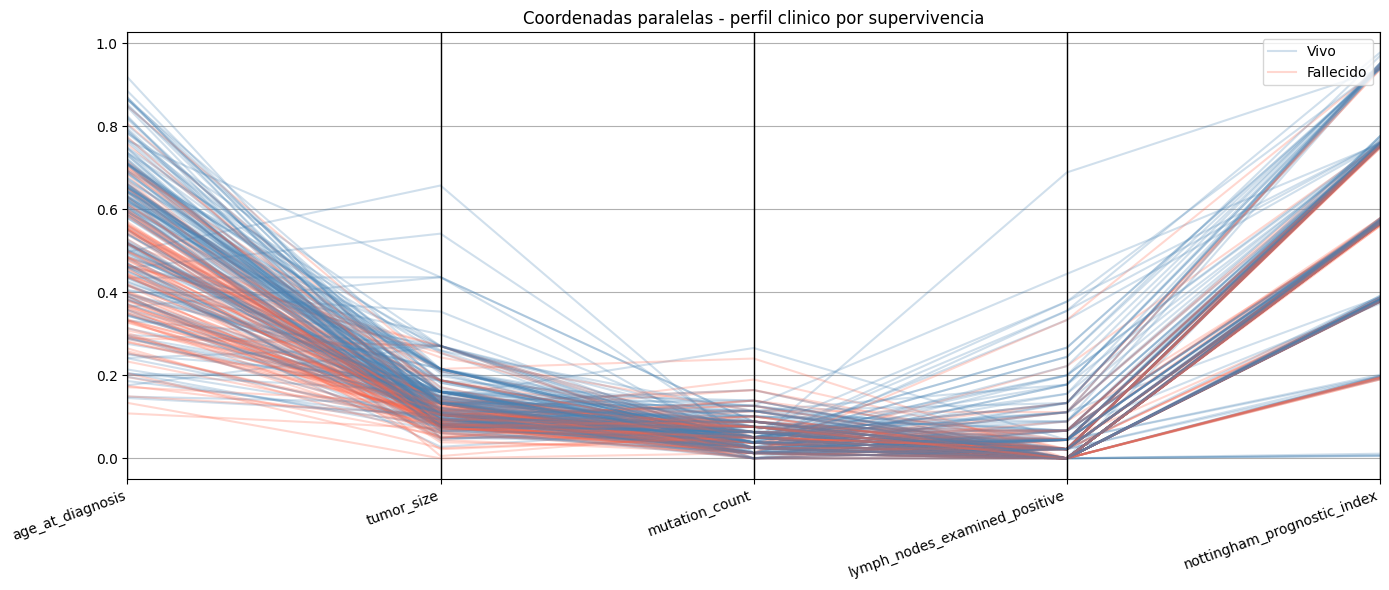

In [ ]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

clinical_vars = [
    'age_at_diagnosis', 'tumor_size', 'mutation_count',
    'lymph_nodes_examined_positive', 'nottingham_prognostic_index'
]

df_pc = df[clinical_vars + ['overall_survival']].dropna().copy()
df_pc[clinical_vars] = MinMaxScaler().fit_transform(df_pc[clinical_vars])
df_pc['overall_survival'] = df_pc['overall_survival'].map({0: 'Vivo', 1: 'Fallecido'})

df_sample = df_pc.sample(300, random_state=42)

fig, ax = plt.subplots(figsize=(14, 6))
parallel_coordinates(df_sample, class_column='overall_survival',
                     color=['steelblue', 'tomato'], alpha=0.25, ax=ax)
ax.set_title('Coordenadas paralelas - perfil clinico por supervivencia')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Cada línea representa un paciente y los ejes están normalizados en [0,1].
Las variables `tumor_size`, `mutation_count` y `lymph_nodes_examined_positive`
muestran poca varianza (líneas concentradas cerca de cero), lo que confirma que
la mayoría de pacientes tiene valores bajos en estas variables. La separación más
clara entre grupos (rojo = Vivo, azul = Fallecido) ocurre en el
`nottingham_prognostic_index`: los pacientes fallecidos tienden a tener valores
más altos en este índice de riesgo, lo cual es consistente con su definición clínica.
Las pocas líneas que permanecen altas a lo largo de todos los ejes corresponden
a pacientes con perfiles clínicos atípicamente severos (posibles outliers).

También es posible visualizar los datos mediante un diagrama de estrella

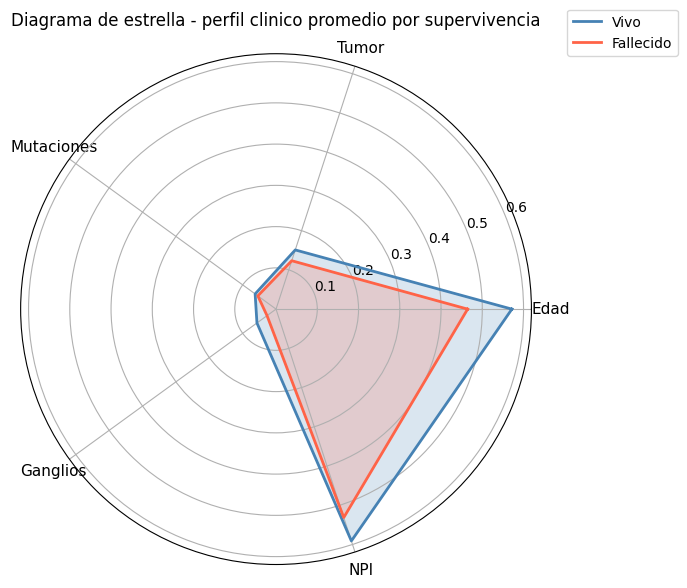

In [ ]:
clinical_vars = [
    'age_at_diagnosis', 'tumor_size', 'mutation_count',
    'lymph_nodes_examined_positive', 'nottingham_prognostic_index'
]
labels_cortos = ['Edad', 'Tumor', 'Mutaciones', 'Ganglios', 'NPI']

# Normalizar con el rango real de los pacientes
col_min = df[clinical_vars].min()
col_max = df[clinical_vars].max()

group_means = df.groupby('overall_survival')[clinical_vars].mean()
group_means_norm = (group_means - col_min) / (col_max - col_min)

# Angulos del polígono
N = len(clinical_vars)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors    = {0: 'steelblue', 1: 'tomato'}
etiquetas = {0: 'Vivo', 1: 'Fallecido'}

for grupo in [0, 1]:
    vals = group_means_norm.loc[grupo].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=colors[grupo], linewidth=2, label=etiquetas[grupo])
    ax.fill(angles, vals, color=colors[grupo], alpha=0.2)

ax.set_thetagrids(np.degrees(angles[:-1]), labels_cortos, fontsize=11)
ax.set_title('Diagrama de estrella - perfil clinico promedio por supervivencia',
             fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

Los dos polígonos representan el perfil clínico promedio de cada grupo,
normalizado contra el rango real de los pacientes. El grupo Fallecido (rojo)
supera al grupo Vivo (azul) en NPI y en Edad, que son las dos variables donde
los polígonos divergen más visiblemente. En Mutaciones y Ganglios ambos grupos
tienen promedios muy similares y cercanos a cero, lo que confirma que estas
variables tienen poca capacidad discriminativa a nivel de promedio grupal.
Tumor muestra una diferencia pequeña pero el grupo Vivo tiene un promedio
ligeramente mayor, posiblemente por sesgo de supervivencia en pacientes
que recibieron tratamiento. En conjunto, el NPI es el rasgo que más distingue
los dos perfiles, siendo consistente con lo observado en las coordenadas paralelas.

y se implementa una visualización de caras de Chernoff

In [ ]:
feature_cols = [
    'age_at_diagnosis',               # ancho de cara
    'tumor_size',                     # alto de cara
    'mutation_count',                 # tamaño de ojos
    'nottingham_prognostic_index',    # angulo de cejas (alto NPI = cejas fruncidas)
    'lymph_nodes_examined_positive',  # curvatura de boca (muchos nodos = triste)
    'overall_survival_months'         # tamaño de nariz
]

In [ ]:
def draw_face(ax, feats, titulo=''):
    fw  = 0.25 + feats[0] * 0.50   # antes 0.30 -> ahora 0.50
    fh  = 0.25 + feats[1] * 0.45   # antes 0.25 -> ahora 0.45
    es  = 0.03 + feats[2] * 0.10   # antes 0.07 -> ahora 0.10
    ba  = -60  + feats[3] * 120    # antes 80   -> ahora 120
    mc  = feats[4]
    ns  = 0.02 + feats[5] * 0.06   # antes 0.04 -> ahora 0.06
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_aspect('equal'); ax.axis('off')

    # cara
    ax.add_patch(mpatches.Ellipse((0, 0), fw*2, fh*2,
                                  color='#FFDEAD', ec='black', lw=1.5))
    # ojos
    for ex in [-0.18, 0.18]:
        ax.add_patch(mpatches.Ellipse((ex, 0.15), es*2, es,
                                      color='#333333'))

    # cejas
    for ex, sign in [(-0.18, 1), (0.18, -1)]:
        ang = np.deg2rad(ba * sign)
        dx, dy = 0.10*np.cos(ang), 0.10*np.sin(ang)
        ax.plot([ex-dx, ex+dx], [0.28-dy, 0.28+dy],
                color='black', lw=2.5)

    # nariz
    ax.add_patch(mpatches.Ellipse((0, -0.05), ns, ns*1.8,
                                  color='#CD853F', ec='black', lw=0.8))

    # boca: sonrisa (mc>0.5) o gesto neutro/triste
    theta1, theta2 = (200, 340) if mc > 0.5 else (20, 160)
    h_boca = 0.05 + abs(mc - 0.5) * 0.20
    ax.add_patch(Arc((0, -0.30), 0.35, h_boca,
                     angle=0, theta1=theta1, theta2=theta2,
                     color='#CC0000', lw=2))

    ax.set_title(titulo, fontsize=8, pad=3)



In [ ]:
def plot_chernoff(df_in, feature_cols, label_col, n=16):
    qt = QuantileTransformer(output_distribution='uniform', random_state=42)
    df_norm = df_in[feature_cols + [label_col]].dropna().copy()
    df_norm[feature_cols] = qt.fit_transform(df_norm[feature_cols])
    # ... resto igual
    muestra = df_norm.sample(min(n, len(df_norm)), random_state=42)

    cols = 4
    rows = (len(muestra) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.8, rows*2.8))
    axes = axes.flatten()

    for i, (_, row) in enumerate(muestra.iterrows()):
        feats = [row[c] for c in feature_cols]
        label = 'Vivo' if row[label_col] == 0 else 'Fallecido'
        draw_face(axes[i], feats, titulo=label)

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    leyenda = '\n'.join([f'{k+1}. {v}' for k, v in enumerate(feature_cols)])
    fig.text(0.01, -0.01,
             f'Mapeo rasgo -> variable:\n1.ancho=edad  2.alto=tumor  '
             f'3.ojos=mutaciones\n4.cejas=NPI  5.boca=ganglios  6.nariz=meses superv.',
             fontsize=7, va='top', family='monospace')

    fig.suptitle('Caras de Chernoff - perfil clinico de pacientes', fontsize=13)
    plt.tight_layout()
    plt.show()



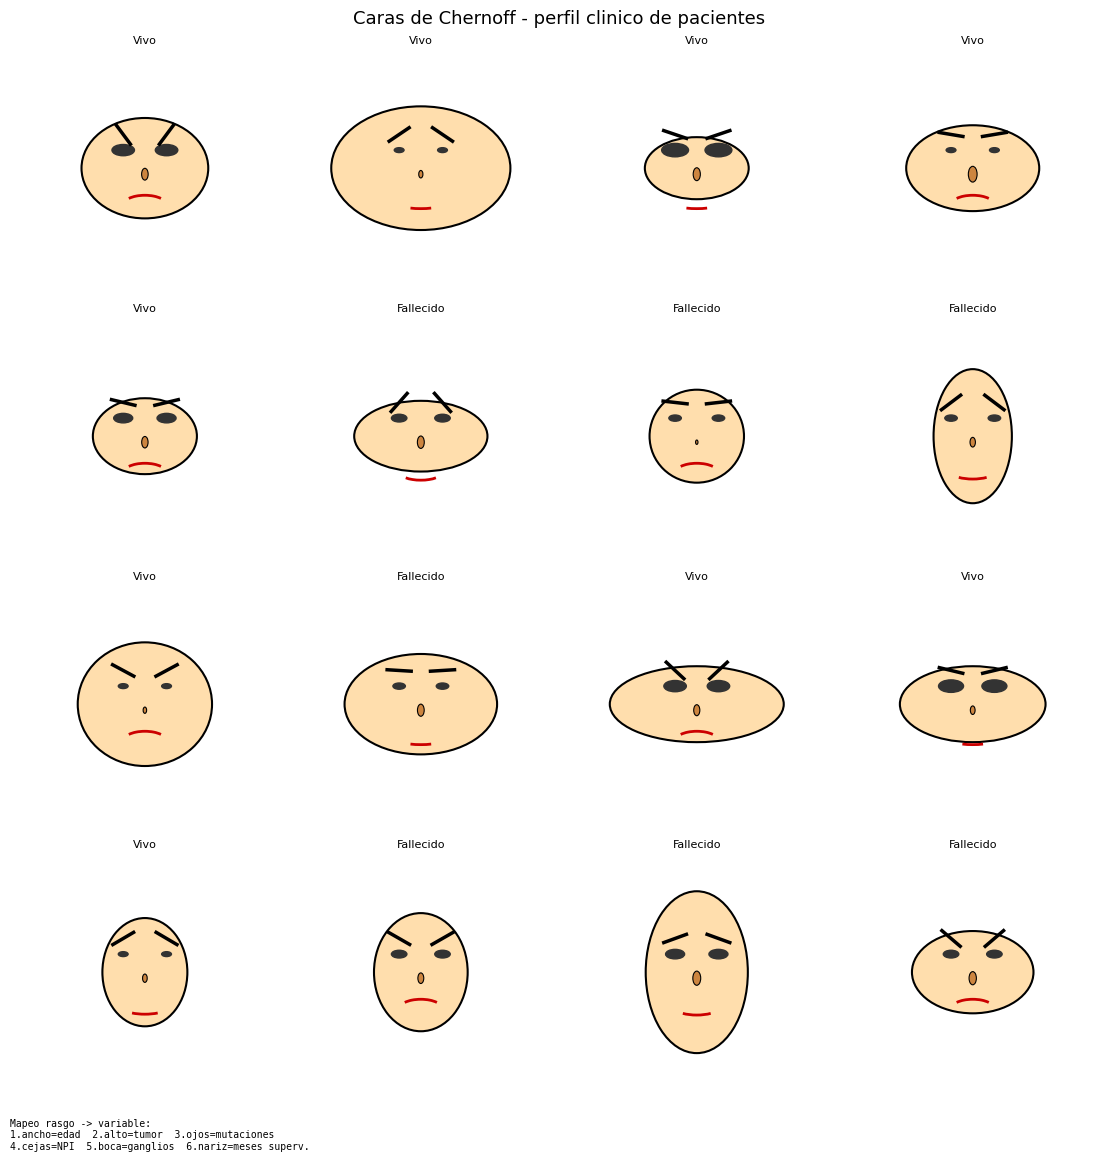

In [ ]:
plot_chernoff(df, feature_cols, label_col='overall_survival', n=16)


Cada cara representa un paciente individual. Los rasgos codifican variables
clínicas según el mapeo indicado al pie de la figura.

Se observan patrones reconocibles entre grupos: los pacientes Fallecidos
tienden a tener caras más alargadas verticalmente (tumor grande), cejas más
inclinadas hacia abajo (NPI alto) y ojos más grandes y juntos (más mutaciones).
Los pacientes Vivos muestran caras más redondeadas y rasgos más neutros en
general. La cara de la fila 2, columna 3 (Fallecido) es llamativa: cara muy
achatada horizontalmente con cejas levantadas, lo que indica un paciente con
tumor pequeño pero NPI bajo, un perfil atípico dentro de los fallecidos.

La utilidad de esta visualización es precisamente esa: el cerebro humano detecta
rostros "raros" o "distintos" de forma inmediata, lo que permite identificar
observaciones atípicas que podrían pasar desapercibidas en una tabla numérica.
La limitación principal es que el mapeo rasgo-variable es arbitrario, por lo que
las conclusiones siempre deben contrastarse con las estadísticas descriptivas.

## Perfil clínico

### Correlación entre variables

<Axes: >

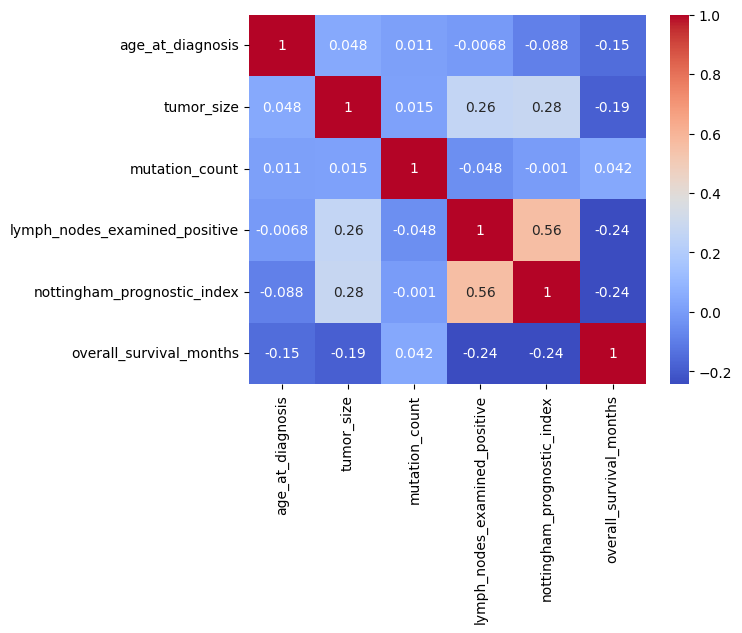

In [ ]:
clinicas_num = df[
[
'age_at_diagnosis',
'tumor_size',
'mutation_count',
'lymph_nodes_examined_positive',
'nottingham_prognostic_index',
'overall_survival_months'
]]

corr = clinicas_num.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

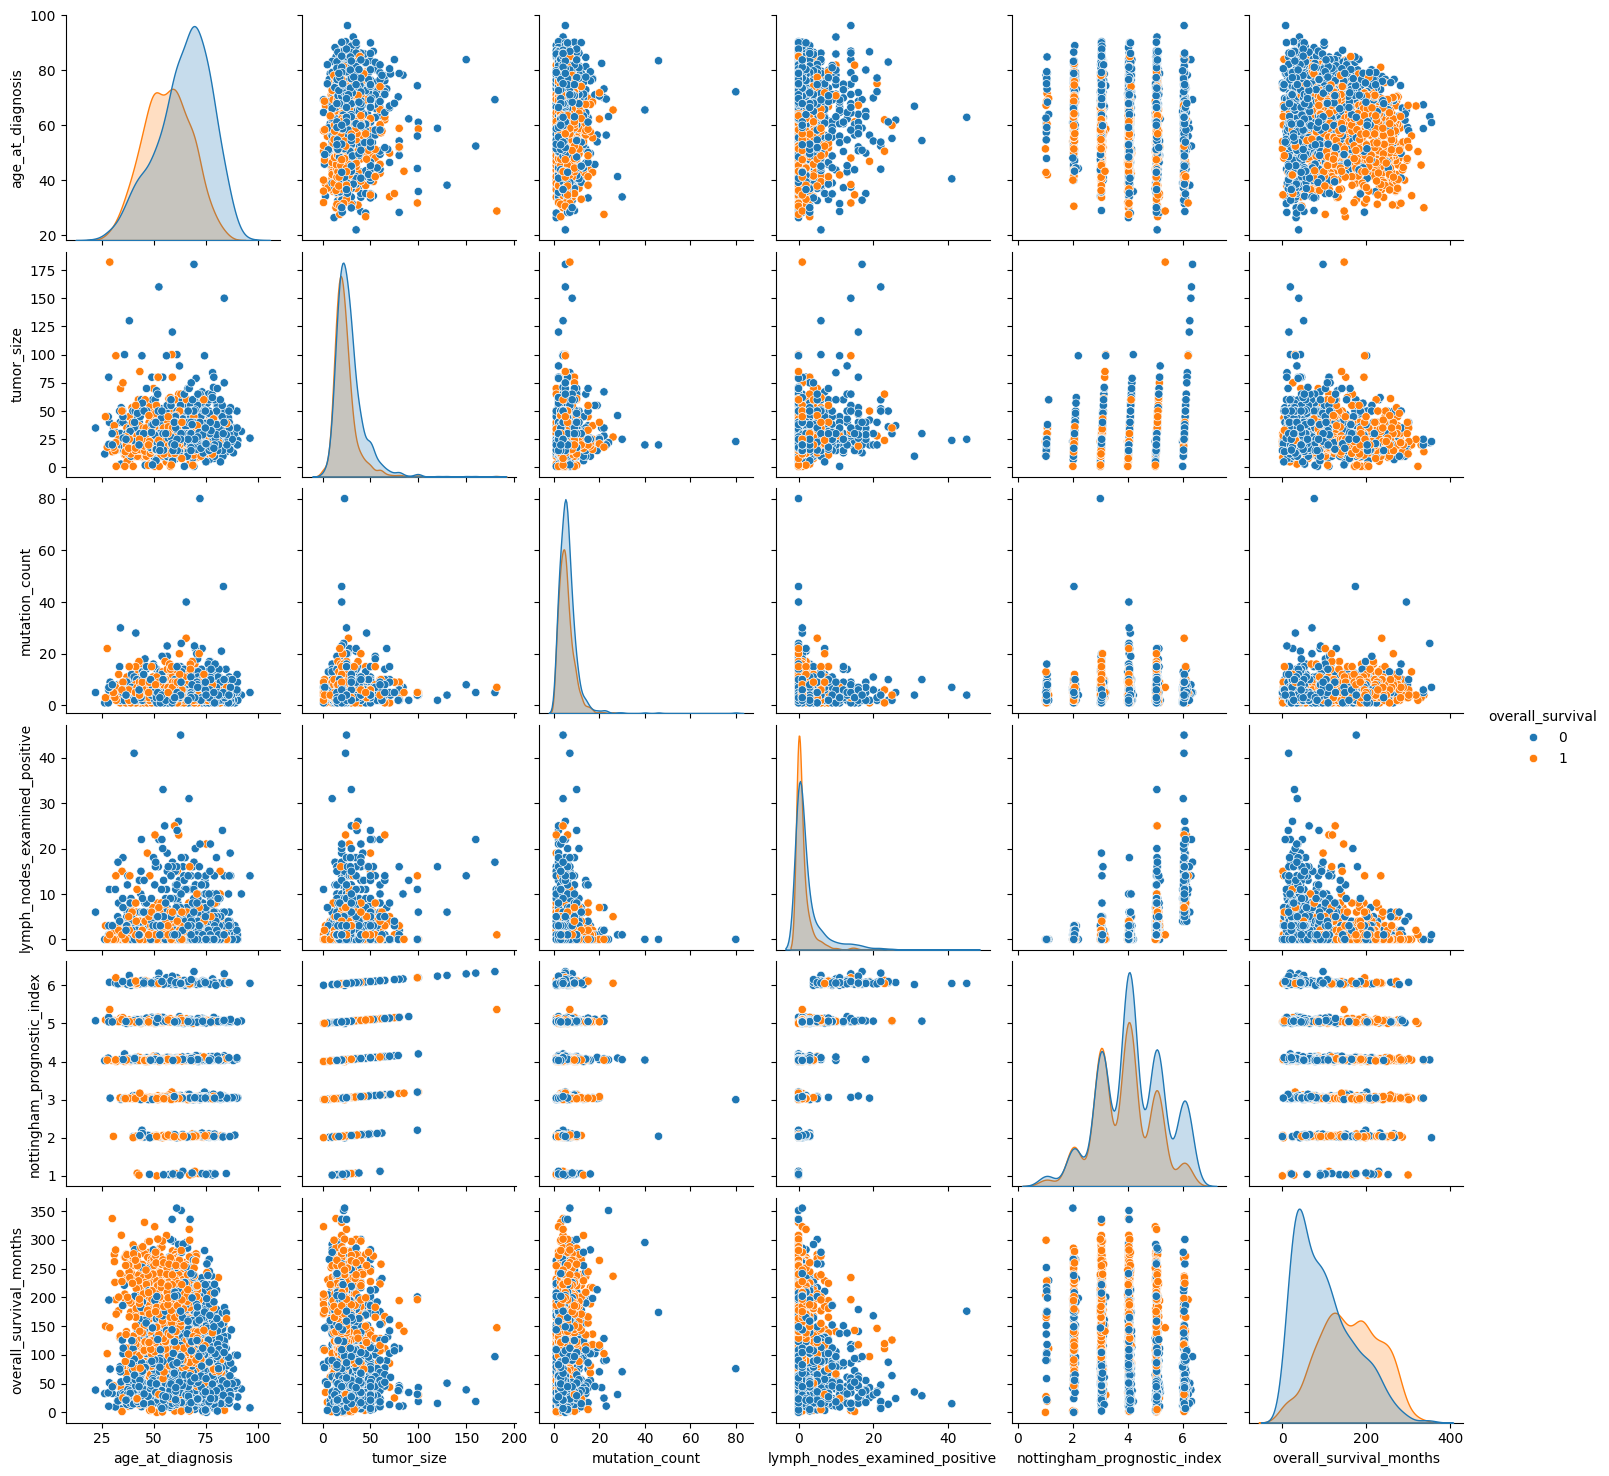

In [ ]:
sns.pairplot(df, vars=clinicas_num, hue='overall_survival')

### Relación con la edad

In [ ]:
df.groupby('overall_survival')['age_at_diagnosis'].describe()

,count,mean,std,min,25%,50%,75%,max
overall_survival,,,,,,,,
0,1103.0,64.444751,13.041817,21.93,56.36,66.36,74.30,96.29
1,801.0,56.463408,11.377459,26.72,48.13,56.74,64.43,85.21


<Axes: xlabel='overall_survival', ylabel='age_at_diagnosis'>

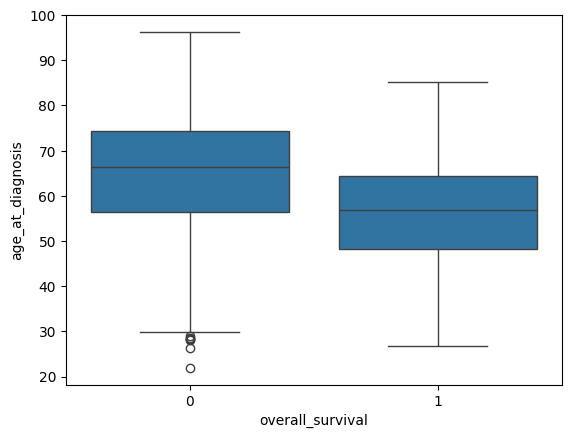

In [ ]:
sns.boxplot(data=df, x='overall_survival', y='age_at_diagnosis')

### Relación con el tamaño del tumor

In [ ]:
df.groupby('overall_survival')['tumor_size'].describe()

,count,mean,std,min,25%,50%,75%,max
overall_survival,,,,,,,,
0,1103.0,28.301714,16.115662,1.0,20.0,25.0,33.0,180.0
1,801.0,23.317066,13.004326,1.0,16.0,20.0,26.0,182.0


<Axes: xlabel='overall_survival', ylabel='tumor_size'>

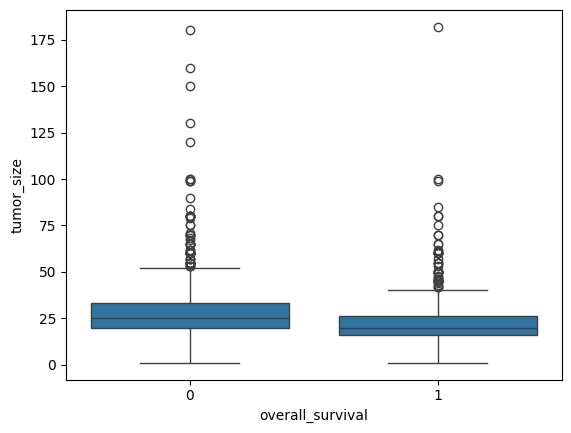

In [ ]:
sns.boxplot(data=df, x='overall_survival', y='tumor_size')

### Relación con el conteo de mutaciones

In [ ]:
df.groupby('overall_survival')['mutation_count'].describe()

,count,mean,std,min,25%,50%,75%,max
overall_survival,,,,,,,,
0,1103.0,5.950136,4.451010,1.0,4.0,5.0,7.0,80.0
1,801.0,5.310861,3.280167,1.0,3.0,5.0,7.0,26.0


<Axes: xlabel='overall_survival', ylabel='mutation_count'>

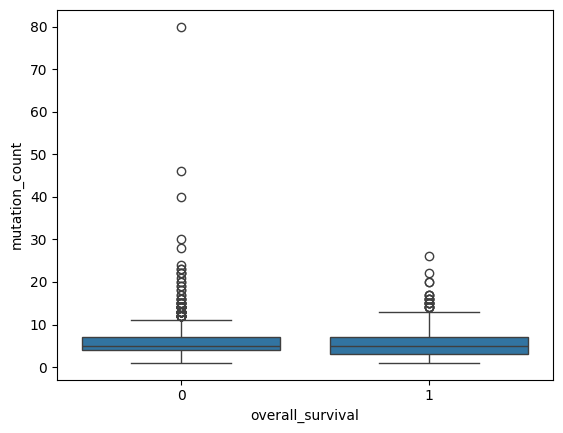

In [ ]:
sns.boxplot(data=df, x='overall_survival', y='mutation_count')

### Relación con el grado histológico

In [ ]:
df.groupby('overall_survival')['neoplasm_histologic_grade'].value_counts(normalize=True)

overall_survival  neoplasm_histologic_grade
0                 3.0                          0.535613
                  2.0                          0.393162
                  1.0                          0.071225
1                 3.0                          0.465982
                  2.0                          0.418485
                  1.0                          0.115533
Name: proportion, dtype: float64

<Axes: xlabel='neoplasm_histologic_grade', ylabel='count'>

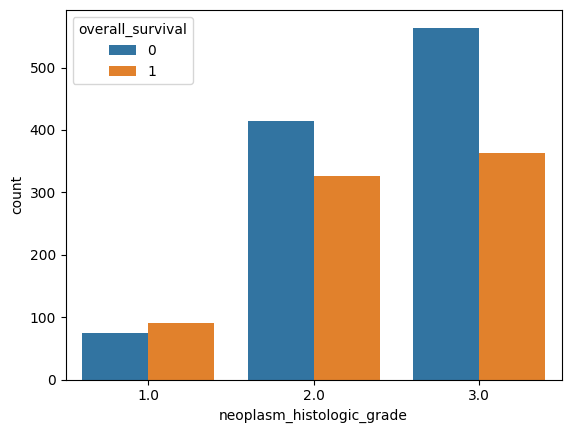

In [ ]:
sns.countplot(data=df,
              x='neoplasm_histologic_grade',
              hue='overall_survival')

### Relación con el tamaño del tumor

In [ ]:
df.groupby('overall_survival')['tumor_stage'].value_counts(normalize=True)

overall_survival  tumor_stage
0                 2.0            0.436990
                  Unknown        0.281958
                  1.0            0.194923
                  3.0            0.077969
                  4.0            0.007253
                  0.0            0.000907
1                 2.0            0.397004
                  1.0            0.324594
                  Unknown        0.237203
                  3.0            0.036205
                  0.0            0.003745
                  4.0            0.001248
Name: proportion, dtype: float64

<Axes: xlabel='tumor_stage', ylabel='count'>

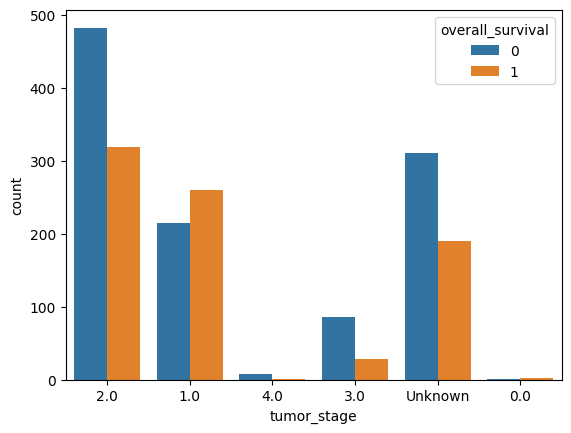

In [ ]:
sns.countplot(data=df,
              x='tumor_stage',
              hue='overall_survival')

### Relación con tratamientos médicos

In [ ]:
df.groupby('overall_survival')['chemotherapy'].value_counts(normalize=True)

overall_survival  chemotherapy
0                 0               0.807797
                  1               0.192203
1                 0               0.770287
                  1               0.229713
Name: proportion, dtype: float64

<Axes: xlabel='chemotherapy', ylabel='count'>

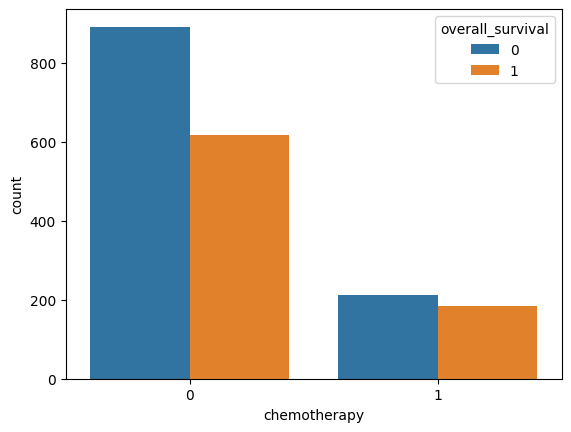

In [ ]:
sns.countplot(data=df,
              x='chemotherapy',
              hue='overall_survival')

In [ ]:
df.groupby('overall_survival')['hormone_therapy'].value_counts(normalize=True)

overall_survival  hormone_therapy
0                 1                  0.629193
                  0                  0.370807
1                 1                  0.599251
                  0                  0.400749
Name: proportion, dtype: float64

<Axes: xlabel='hormone_therapy', ylabel='count'>

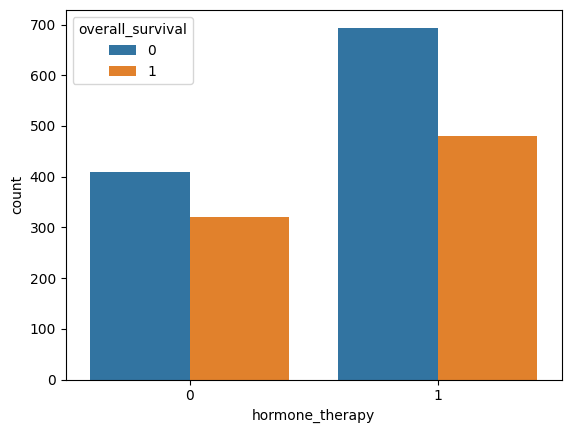

In [ ]:
sns.countplot(data=df,
              x='hormone_therapy',
              hue='overall_survival')

In [ ]:
df.groupby('overall_survival')['radio_therapy'].value_counts(normalize=True)

overall_survival  radio_therapy
0                 1                0.550317
                  0                0.449683
1                 1                0.661673
                  0                0.338327
Name: proportion, dtype: float64

<Axes: xlabel='radio_therapy', ylabel='count'>

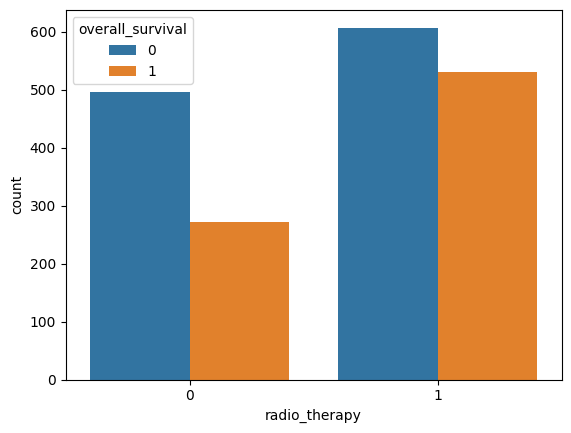

In [ ]:
sns.countplot(data=df,
              x='radio_therapy',
              hue='overall_survival')

### Relación con biomarcadores

In [ ]:
df.groupby('overall_survival')['er_status'].value_counts(normalize=True)

overall_survival  er_status
0                 Positive     0.773345
                  Negative     0.226655
1                 Positive     0.756554
                  Negative     0.243446
Name: proportion, dtype: float64

<Axes: xlabel='er_status', ylabel='count'>

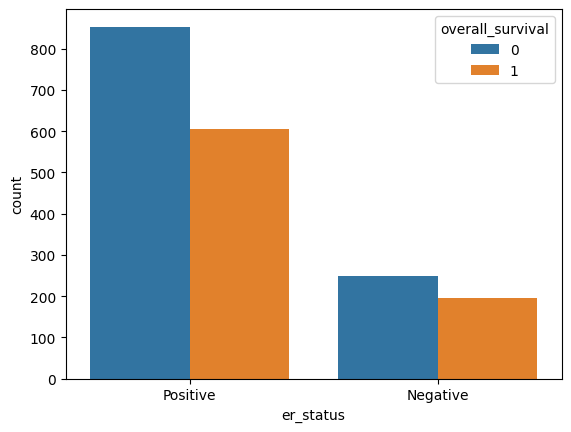

In [ ]:
sns.countplot(data=df,
              x='er_status',
              hue='overall_survival')

In [ ]:
df.groupby('overall_survival')['pr_status'].value_counts(normalize=True)

overall_survival  pr_status
0                 Positive     0.520399
                  Negative     0.479601
1                 Positive     0.543071
                  Negative     0.456929
Name: proportion, dtype: float64

<Axes: xlabel='pr_status', ylabel='count'>

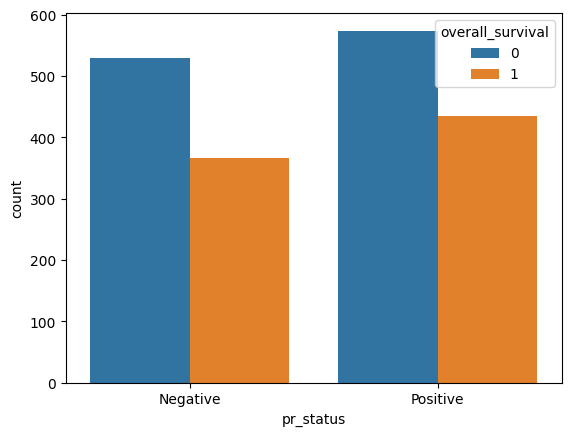

In [ ]:
sns.countplot(data=df,
              x='pr_status',
              hue='overall_survival')

In [ ]:
df.groupby('overall_survival')['her2_status'].value_counts(normalize=True)

overall_survival  her2_status
0                 Negative       0.866727
                  Positive       0.133273
1                 Negative       0.888889
                  Positive       0.111111
Name: proportion, dtype: float64

<Axes: xlabel='her2_status', ylabel='count'>

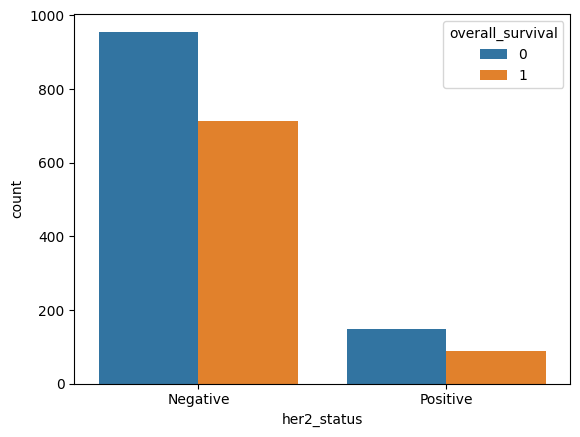

In [ ]:
sns.countplot(data=df,
              x='her2_status',
              hue='overall_survival')

### Relación con la menopusia de la paciente

In [ ]:
df.groupby('overall_survival')['inferred_menopausal_state'].value_counts(normalize=True)

overall_survival  inferred_menopausal_state
0                 Post                         0.844062
                  Pre                          0.155938
1                 Post                         0.701623
                  Pre                          0.298377
Name: proportion, dtype: float64

<Axes: xlabel='inferred_menopausal_state', ylabel='count'>

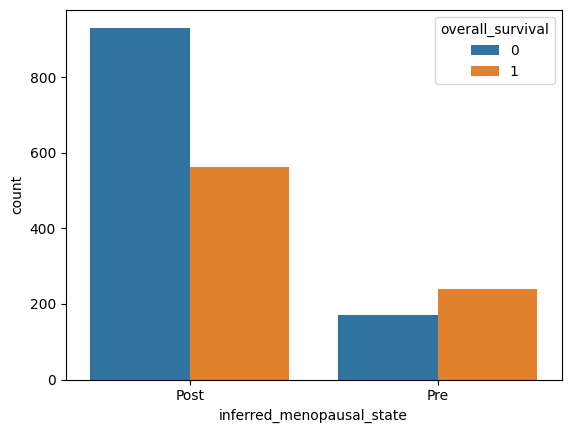

In [ ]:
sns.countplot(data=df,
              x='inferred_menopausal_state',
              hue='overall_survival')

### Relación con el tipo de cirugía

In [ ]:
df.groupby('overall_survival')['type_of_breast_surgery'].value_counts(normalize=True)

overall_survival  type_of_breast_surgery
0                 MASTECTOMY                0.677686
                  BREAST CONSERVING         0.322314
1                 BREAST CONSERVING         0.509458
                  MASTECTOMY                0.490542
Name: proportion, dtype: float64

<Axes: xlabel='type_of_breast_surgery', ylabel='count'>

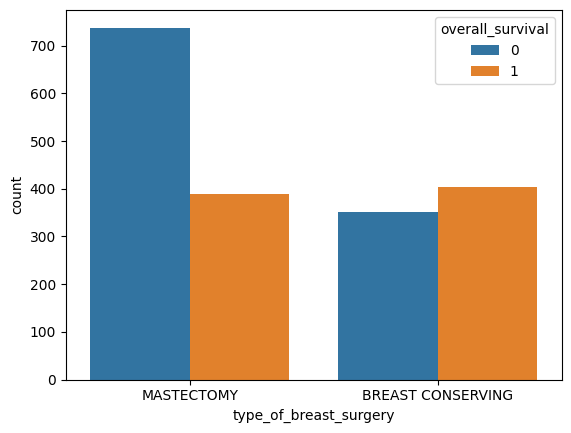

In [ ]:
sns.countplot(data=df,
              x='type_of_breast_surgery',
              hue='overall_survival')

## Perfil mutaciones

In [ ]:
import seaborn as sns

Hacemos binaria la presencia/ausencia de cada gen mutado

In [ ]:
for col in df_mut.columns:
    df_mut[col]=df_mut[col].apply(lambda x: 1 if x != '0' else 0)
df_mut.head()

/tmp/ipython-input-2480773526.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mut[col]=df_mut[col].apply(lambda x: 1 if x != '0' else 0)


,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1


In [ ]:
conteo_mut = df_mut.apply(pd.Series.value_counts)
conteo_mut

,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,1109,1245,1578,1593,1670,1672,1674,1706,1728,1729,...,1900,1900,1900,1901,1901,878,1902,878,1902,879
1,795,659,326,311,234,232,230,198,176,175,...,4,4,4,3,3,1026,2,1026,2,1025


In [ ]:
conteo_mut = conteo_mut.rename_axis('mutation_status')
df_melted = conteo_mut.reset_index().melt(id_vars='mutation_status', var_name='gene', value_name='count')
df_melted.head()

,mutation_status,gene,count
0,0,pik3ca_mut,1109
1,1,pik3ca_mut,795
2,0,tp53_mut,1245
3,1,tp53_mut,659
4,0,muc16_mut,1578


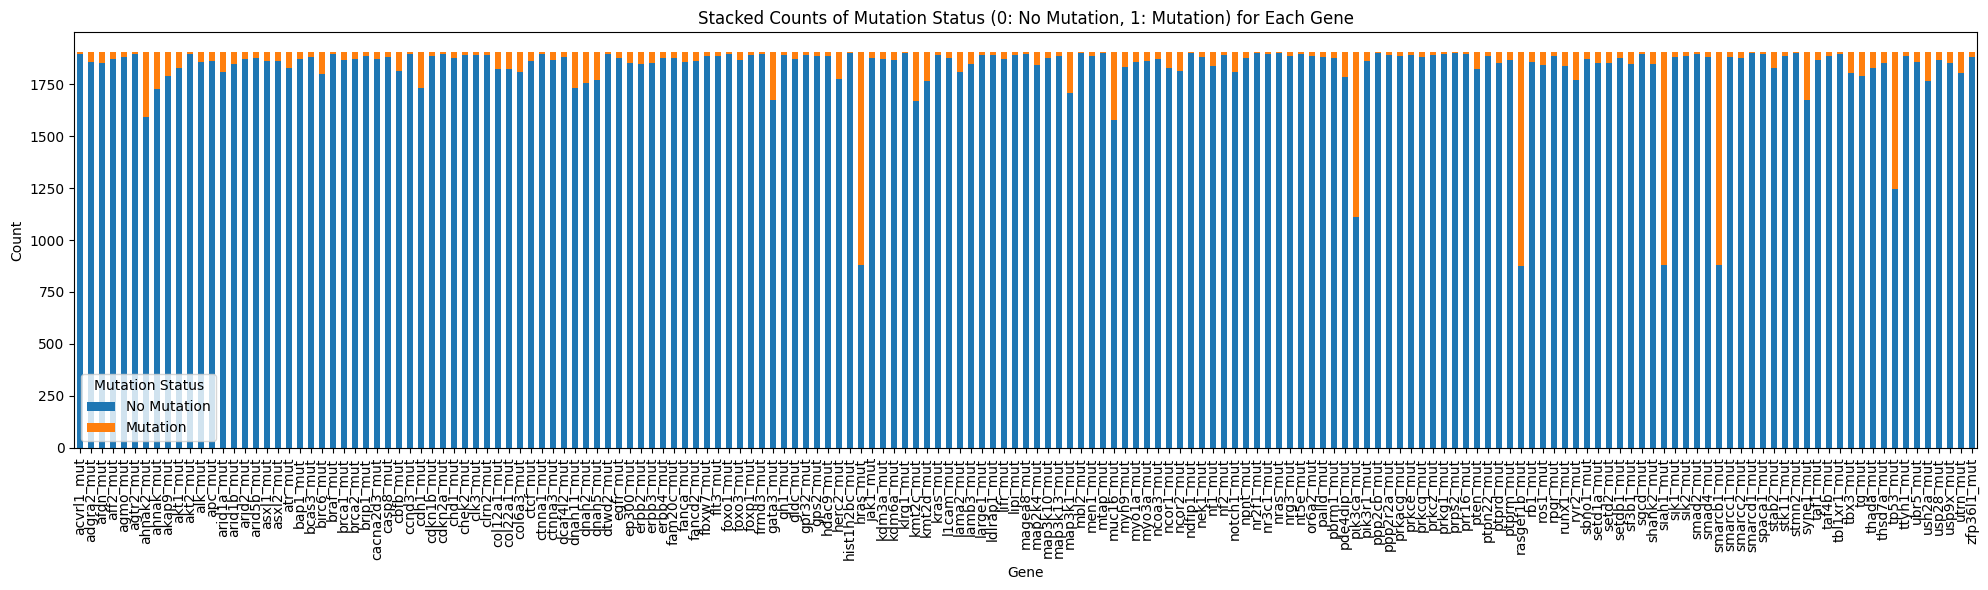

In [ ]:
df_pivoted = df_melted.pivot(index='gene', columns='mutation_status', values='count').fillna(0)

plt.figure(figsize=(20, 6))
df_pivoted.plot(kind='bar', stacked=True, figsize=(20, 6), ax=plt.gca())

plt.title('Stacked Counts of Mutation Status (0: No Mutation, 1: Mutation) for Each Gene')
plt.xlabel('Gene')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Mutation Status', labels=['No Mutation', 'Mutation'])
plt.tight_layout()
plt.show()

## Perfil génico

In [ ]:
df_gene.describe()

,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1904.000000,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03
mean,-6.302521e-07,-4.201681e-07,3.676471e-07,-8.928571e-07,6.302521e-07,-2.100840e-07,0.000002,7.463684e-18,-3.676471e-07,-0.000001,...,4.726891e-07,-3.676471e-07,-9.453782e-07,-1.050420e-07,-0.000002,3.676471e-07,4.726891e-07,7.878151e-07,0.000000,3.731842e-18
std,1.000262e+00,1.000262e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000262e+00,1.000263,1.000262e+00,1.000263e+00,1.000262,...,1.000263e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000262,1.000264e+00,1.000262e+00,1.000263e+00,1.000262,1.000262e+00
min,-2.444400e+00,-2.783500e+00,-4.384600e+00,-5.932800e+00,-2.481200e+00,-3.170500e+00,-3.323700,-2.688700e+00,-3.689800e+00,-2.968600,...,-2.120800e+00,-3.364800e+00,-2.719400e+00,-4.982700e+00,-2.981700,-3.833300e+00,-3.609300e+00,-1.166900e+00,-2.112600,-1.051600e+00
25%,-7.198500e-01,-6.994750e-01,-6.798250e-01,-5.586500e-01,-6.661500e-01,-6.602250e-01,-0.458600,-7.385500e-01,-6.667750e-01,-0.683925,...,-6.188500e-01,-6.104750e-01,-6.741750e-01,-6.136750e-01,-0.632900,-6.664750e-01,-7.102000e-01,-5.058250e-01,-0.476200,-7.260000e-01
50%,-1.244500e-01,-5.820000e-02,-2.210000e-02,1.098500e-01,-3.010000e-02,-4.200000e-03,0.115550,-1.311000e-01,-1.445000e-02,-0.054800,...,-2.456500e-01,-4.690000e-02,-1.422500e-01,-5.175000e-02,-0.026650,7.000000e-04,-2.980000e-02,-2.885500e-01,-0.133400,-4.248000e-01
75%,5.532250e-01,6.290000e-01,6.400000e-01,6.426250e-01,6.447500e-01,6.901500e-01,0.649800,5.431250e-01,6.387250e-01,0.668925,...,3.306000e-01,5.144500e-01,5.146000e-01,5.787750e-01,0.590350,6.429000e-01,5.957250e-01,6.022500e-02,0.270375,4.284000e-01
max,4.554200e+00,3.737900e+00,4.615000e+00,3.254100e+00,4.289800e+00,3.824200e+00,2.820900,4.538200e+00,5.371300e+00,6.178600,...,6.534900e+00,1.027030e+01,6.329000e+00,4.571300e+00,12.742300,3.938800e+00,3.833400e+00,1.088490e+01,12.643900,3.284400e+00


<Axes: ylabel='Count'>

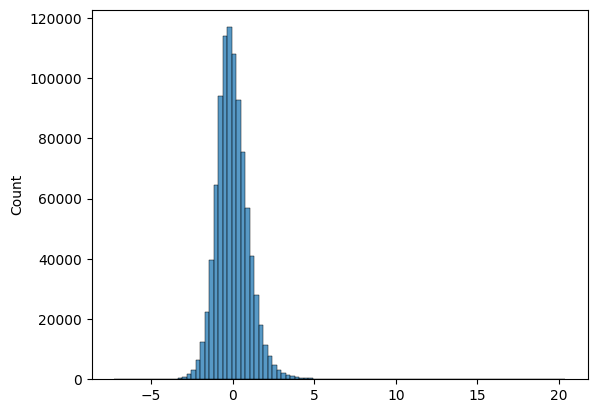

In [ ]:
sns.histplot(df_gene.values.flatten(), bins=100)

In [ ]:
var_genes = df_gene.var().sort_values(ascending=False)
var_genes.head(20)


,0
nfkb1,1.000530
ptprm,1.000529
cyp3a7,1.000529
e2f1,1.000529
pdgfra,1.000529
ubr5,1.000529
rab25,1.000528
hsd17b3,1.000528
nr2f1,1.000528
ptk2,1.000528


In [ ]:
top = var_genes.head(10).index

genes_var = df.groupby('overall_survival')[top].mean().T

<Axes: xlabel='overall_survival'>

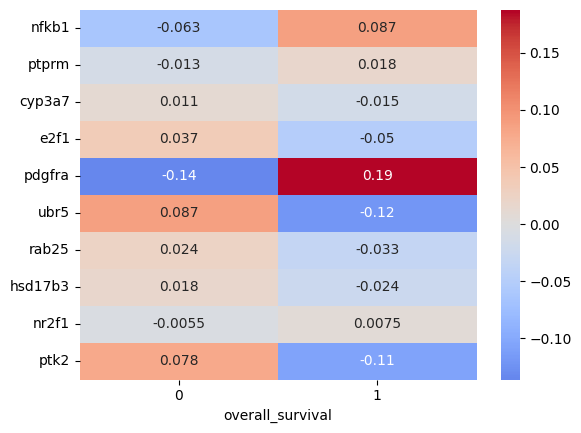

In [ ]:
sns.heatmap(
    genes_var,
    cmap='coolwarm',
    center=0,
    annot=True
)

<Axes: xlabel='overall_survival', ylabel='genetic_instability'>

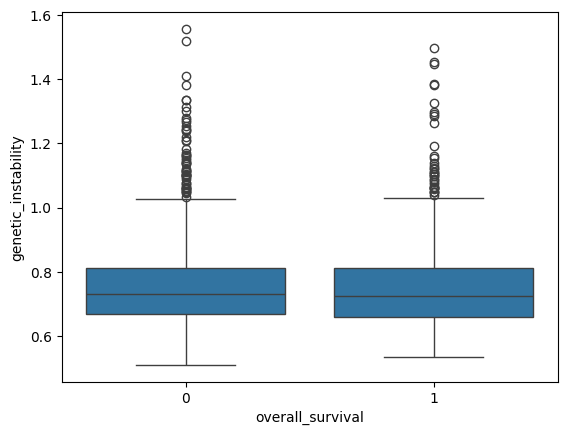

In [ ]:
df['genetic_instability'] = (df_gene.abs().mean(axis=1))
sns.boxplot(data=df, x='overall_survival', y='genetic_instability')


<Axes: xlabel='overall_survival', ylabel='gene_variability'>

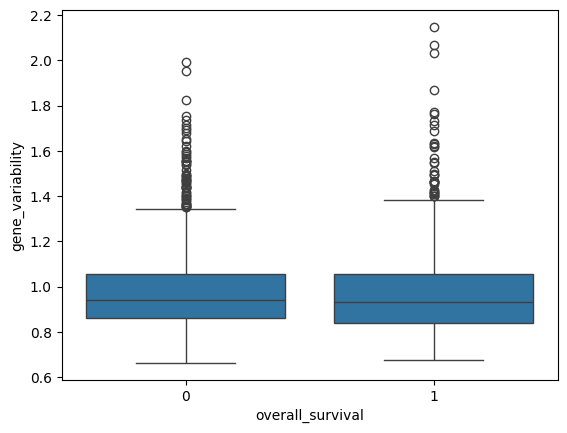

In [ ]:
df['gene_variability'] = df_gene.std(axis=1)
sns.boxplot(data=df, x='overall_survival', y='gene_variability')